Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
%matplotlib inline

Load Dataset

In [2]:
df = pd.read_csv('/home/ankit_samal/ML project/data/raw/Banglore_traffic_Dataset.csv')
print("Shape:", df.shape)
df.head()

Shape: (8936, 16)


,Date,Area Name,Road/Intersection Name,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Public Transport Usage,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count,Weather Conditions,Roadwork and Construction Activity
0,2022-01-01,Indiranagar,100 Feet Road,50590,50.230299,1.500000,100.000000,100.000000,0,151.180,70.632330,84.044600,85.403629,111,Clear,No
1,2022-01-01,Indiranagar,CMH Road,30825,29.377125,1.500000,100.000000,100.000000,1,111.650,41.924899,91.407038,59.983689,100,Clear,No
2,2022-01-01,Whitefield,Marathahalli Bridge,7399,54.474398,1.039069,28.347994,36.396525,0,64.798,44.662384,61.375541,95.466020,189,Clear,No
3,2022-01-01,Koramangala,Sony World Junction,60874,43.817610,1.500000,100.000000,100.000000,1,171.748,32.773123,75.547092,63.567452,111,Clear,No
4,2022-01-01,Koramangala,Sarjapur Road,57292,41.116763,1.500000,100.000000,100.000000,3,164.584,35.092601,64.634762,93.155171,104,Clear,No


Basic Info

In [3]:
print("=== Data Types ===")
print(df.dtypes)
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Basic Statistics ===")
df.describe()

=== Data Types ===
Date                                      str
Area Name                                 str
Road/Intersection Name                    str
Traffic Volume                          int64
Average Speed                         float64
Travel Time Index                     float64
Congestion Level                      float64
Road Capacity Utilization             float64
Incident Reports                        int64
Environmental Impact                  float64
Public Transport Usage                float64
Traffic Signal Compliance             float64
Parking Usage                         float64
Pedestrian and Cyclist Count            int64
Weather Conditions                        str
Roadwork and Construction Activity        str
dtype: object

=== Missing Values ===
Date                                  0
Area Name                             0
Road/Intersection Name                0
Traffic Volume                        0
Average Speed                         0
Travel 

,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Public Transport Usage,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count
count,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000
mean,29236.048120,39.447427,1.375554,80.818041,92.029215,1.570389,108.472096,45.086651,79.950243,75.155597,114.533348
std,13001.808801,10.707244,0.165319,23.533182,16.583341,1.420047,26.003618,20.208460,11.585006,14.409394,36.812573
min,4233.000000,20.000000,1.000039,5.160279,18.739771,0.000000,58.466000,10.006853,60.003933,50.020411,66.000000
25%,19413.000000,31.775825,1.242459,64.292905,97.354990,0.000000,88.826000,27.341191,69.828270,62.545895,94.000000
50%,27600.000000,39.199368,1.500000,92.389018,100.000000,1.000000,105.200000,45.170684,79.992773,75.317610,102.000000
75%,38058.500000,46.644517,1.500000,100.000000,100.000000,2.000000,126.117000,62.426485,89.957358,87.518589,111.000000
max,72039.000000,89.790843,1.500000,100.000000,100.000000,10.000000,194.078000,79.979744,99.993652,99.995049,243.000000


Target Variable Distribution

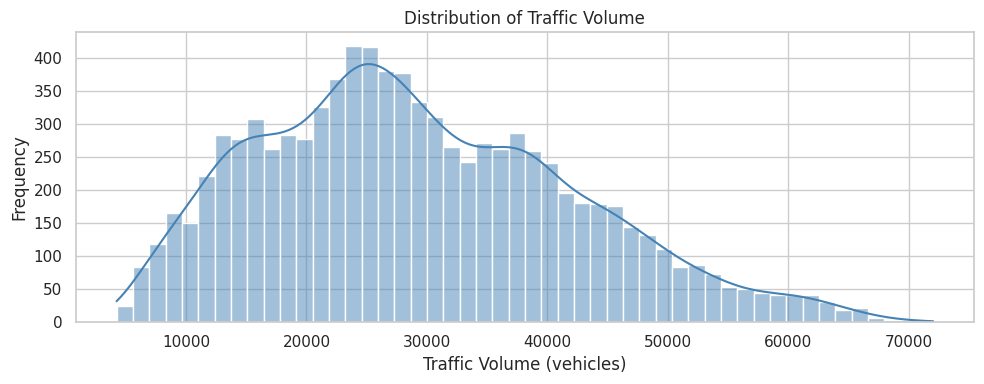

In [4]:
plt.figure(figsize=(10, 4))
sns.histplot(df['Traffic Volume'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of Traffic Volume')
plt.xlabel('Traffic Volume (vehicles)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('../outputs/figures', dpi=150)
plt.show()

Traffic by Hour

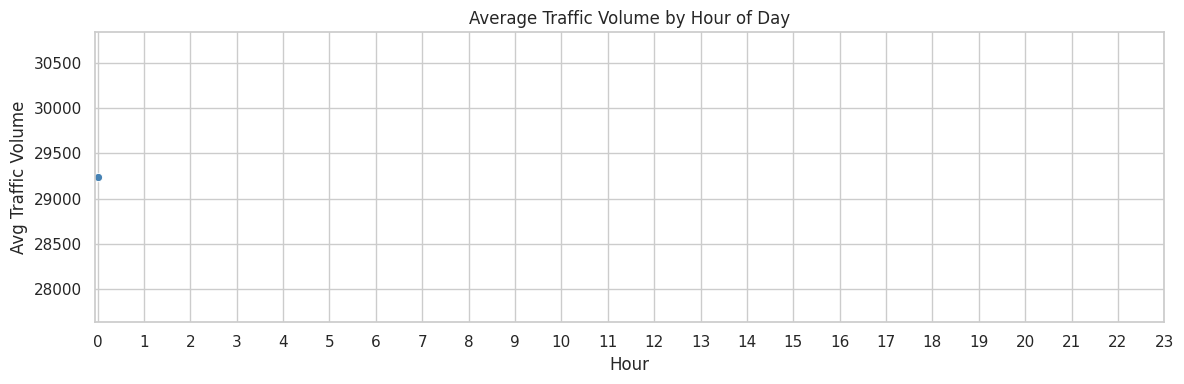

In [5]:
df['Date'] = pd.to_datetime(df['Date'])
df['hour'] = df['Date'].dt.hour

hourly = df.groupby('hour')['Traffic Volume'].mean().reset_index()

plt.figure(figsize=(12, 4))
sns.lineplot(data=hourly, x='hour', y='Traffic Volume', marker='o', color='steelblue')
plt.title('Average Traffic Volume by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Avg Traffic Volume')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig('../outputs/figures/traffic_by_hour.png', dpi=150)
plt.show()

Traffic by Day of Week

/tmp/ipykernel_57370/1544101380.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=daily, x='day_name', y='Traffic Volume', palette='Blues_d')


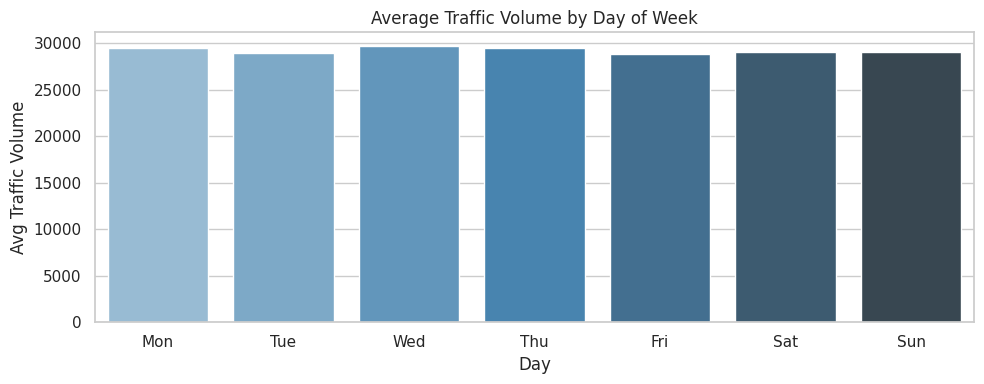

In [6]:
df['day_of_week'] = df['Date'].dt.dayofweek
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

daily = df.groupby('day_of_week')['Traffic Volume'].mean().reset_index()
daily['day_name'] = daily['day_of_week'].map(lambda x: day_names[x])

plt.figure(figsize=(10, 4))
sns.barplot(data=daily, x='day_name', y='Traffic Volume', palette='Blues_d')
plt.title('Average Traffic Volume by Day of Week')
plt.xlabel('Day')
plt.ylabel('Avg Traffic Volume')
plt.tight_layout()
plt.savefig('../outputs/figures/traffic_by_day.png', dpi=150)
plt.show()

Traffic by Area

/tmp/ipykernel_57370/1952517918.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=area_traffic.index, y=area_traffic.values, palette='Blues_d')


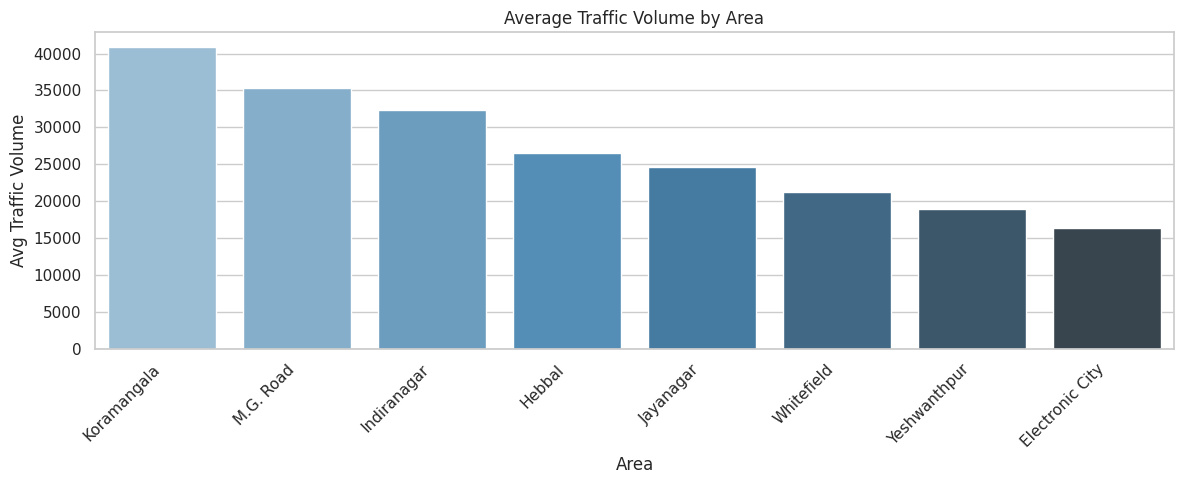

In [7]:
area_traffic = df.groupby('Area Name')['Traffic Volume'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(x=area_traffic.index, y=area_traffic.values, palette='Blues_d')
plt.title('Average Traffic Volume by Area')
plt.xlabel('Area')
plt.ylabel('Avg Traffic Volume')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../outputs/figures/traffic_by_area.png', dpi=150)
plt.show()

Correlation Heatmap

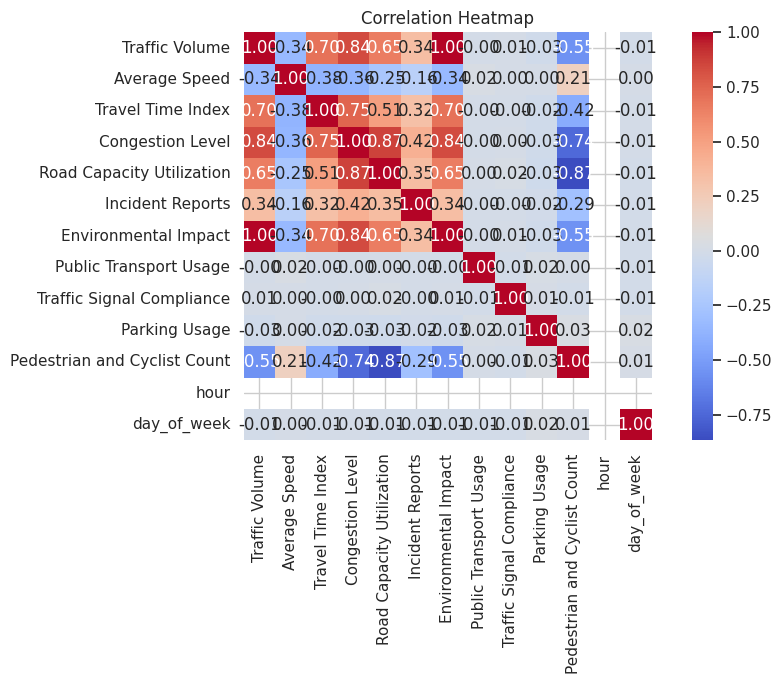

In [8]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(10, 7))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    square=True
)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('../outputs/figures/correlation_heatmap.png', dpi=150)
plt.show()

Rush Hour Analysis

In [9]:
df['is_rush_hour'] = df['hour'].isin([7, 8, 9, 17, 18, 19]).astype(int)
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

print("=== Average Traffic: Rush Hour vs Non-Rush Hour ===")
print(df.groupby('is_rush_hour')['Traffic Volume'].mean())
print("\n=== Average Traffic: Weekday vs Weekend ===")
print(df.groupby('is_weekend')['Traffic Volume'].mean())

=== Average Traffic: Rush Hour vs Non-Rush Hour ===
is_rush_hour
0    29236.04812
Name: Traffic Volume, dtype: float64

=== Average Traffic: Weekday vs Weekend ===
is_weekend
0    29297.170380
1    29083.982045
Name: Traffic Volume, dtype: float64


Summary

In [10]:
print("=== EDA Summary ===")
print(f"Total records     : {len(df)}")
print(f"Date range        : {df['Date'].min()} to {df['Date'].max()}")
print(f"Areas covered     : {df['Area Name'].nunique()}")
print(f"Avg traffic volume: {df['Traffic Volume'].mean():.0f}")
print(f"Max traffic volume: {df['Traffic Volume'].max():.0f}")
print(f"Min traffic volume: {df['Traffic Volume'].min():.0f}")
print(f"\nFigures saved to  : outputs/figures/")

=== EDA Summary ===
Total records     : 8936
Date range        : 2022-01-01 00:00:00 to 2024-08-09 00:00:00
Areas covered     : 8
Avg traffic volume: 29236
Max traffic volume: 72039
Min traffic volume: 4233

Figures saved to  : outputs/figures/
